# Morocco CTVI — Machine Learning Pipeline

**BRCMID Project · Phase 2 · Task 2.4

**Hypothesis:** Morocco's 12 administrative regions cluster into a small number of distinct climate-technology vulnerability typologies that the one-dimensional CTVI ranking obscures.

| Component | Detail |
|-----------|--------|
| Primary model | K-Means clustering with PCA preprocessing (unsupervised) |
| Validation | Ward hierarchical clustering, silhouette analysis |
| Interpretation | Random Forest permutation importance on national CTVI |
| Regions | 12 Moroccan administrative regions |
| Time series | 2000–2024 (national); 2022/23 cross-section (regional) |

---

## 1. Imports & Configuration

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Plot styling
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

# Output directory and random seed
# Plots are shown inline; set SAVE_PATH to a folder to also save PNGs to disk
SAVE_PATH = None  # e.g. '/content/outputs'
np.random.seed(42)

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Load Data

Loads pre-processed regional and national data exported from the CTVI workbook.

| File | Contents |
|------|----------|
| `reg_norm.csv` | Min-max normalised indicators for 12 regions (2022/23 snapshot) |
| `reg_indicators.csv` | Raw (un-normalised) regional indicators |
| `reg_ctvi.csv` | Regional CTVI scores and ranks |
| `nat_norm.csv` | Normalised national indicators, 2000–2024 |
| `nat_data.csv` | Raw national time series |
| `ctvi_nat.csv` | National CTVI composite, 2000–2024 |

In [ ]:
# ── Path to uploaded workbook ────────────────────────────────────────────
XLSX_PATH ="/content/Morocco_CTVI_2000_2024 (1).xlsx"

import pandas as pd
xl = pd.ExcelFile(XLSX_PATH)

# Auto-detects the header row in each sheet (robust to metadata rows)
def _read_sheet(sheet, id_col):
    raw = pd.read_excel(xl, sheet, header=None)
    hdr = next(i for i, r in raw.iterrows() if str(r.iloc[0]).strip() == id_col)
    df  = pd.read_excel(xl, sheet, skiprows=hdr)
    return df[df[id_col].notna()].copy()

# ── Regional sheets (cross-section, 12 regions × 2022/23 anchor) ─────────
reg_norm = _read_sheet('Regional_Normalized', 'Region')  # min-max normalised
reg_raw  = _read_sheet('Regional_Indicators', 'Region')  # raw values
reg_ctvi = _read_sheet('Regional_CTVI',       'Region')  # CTVI scores + ranks

# ── National sheets (time series 2000-2024, rows=indicators, cols=years) ─
def _read_national(sheet):
    df = _read_sheet(sheet, 'Code')
    year_cols = [c for c in df.columns if str(c).replace('.0','').strip().isdigit()]
    wide = df[['Code'] + year_cols].set_index('Code')[year_cols].T
    wide.index = [int(c) for c in wide.index]
    wide.index.name = 'Year'
    return wide.apply(pd.to_numeric, errors='coerce')

nat_norm = _read_national('National_Normalized')

# CTVI time series — extract the CTVI row and transpose to Year index
ctvi_wide = _read_sheet('National_CTVI', 'Code')
year_cols = [c for c in ctvi_wide.columns if str(c).replace('.0','').strip().isdigit()]
ctvi_nat  = ctvi_wide.loc[ctvi_wide['Code'] == 'CTVI', year_cols].T
ctvi_nat.index = [int(c) for c in ctvi_nat.index]
ctvi_nat.index.name = 'Year'
ctvi_nat.columns = ['CTVI']
ctvi_nat = ctvi_nat.apply(pd.to_numeric, errors='coerce')

# ── Feature matrix for ML ────────────────────────────────────────────────
# POP excluded — it is a denominator/context variable, not a vulnerability driver
ML_VARS = ['TEMP_MEAN','PRECIP','SPEI_PROXY','GDP_PC','AGRI_GDP',
           'URBAN','INTERNET','MOBILE','RE_MW','WATER_STRESS']

X       = reg_norm[ML_VARS].astype(float).values
regions = reg_norm['Region'].values

print(f'Regional data:  {reg_norm.shape[0]} regions × {len(ML_VARS)} indicators')
print(f'National data:  {nat_norm.shape[0]} years × {nat_norm.shape[1]} indicators')
print(f'CTVI series:    {ctvi_nat.shape[0]} years ({ctvi_nat.index.min()}–{ctvi_nat.index.max()})')
print(f'Regions: {list(regions)}')
reg_norm[['Region'] + ML_VARS]

Regional data:  12 regions × 10 indicators
National data:  25 years × 21 indicators
CTVI series:    25 years (2000–2024)
Regions: ['Tanger-Tétouan-Al Hoceïma', 'Oriental', 'Fès-Meknès', 'Rabat-Salé-Kénitra', 'Béni Mellal-Khénifra', 'Casablanca-Settat', 'Marrakech-Safi', 'Drâa-Tafilalet', 'Souss-Massa', 'Guelmim-Oued Noun', 'Laâyoune-Sakia El Hamra', 'Dakhla-Oued Ed-Dahab']


,Region,TEMP_MEAN,PRECIP,SPEI_PROXY,GDP_PC,AGRI_GDP,URBAN,INTERNET,MOBILE,RE_MW,WATER_STRESS
0,Tanger-Tétouan-Al Hoceïma,0.363636,0.000000,0.000000,0.773601,0.333333,0.583333,0.32,0.371429,0.000000,0.000000
1,Oriental,0.236364,0.571429,0.428571,0.866441,0.666667,0.690476,0.52,0.485714,0.269231,0.428571
2,Fès-Meknès,0.000000,0.330827,0.114286,0.881100,0.722222,0.571429,0.44,0.428571,0.892308,0.142857
3,Rabat-Salé-Kénitra,0.272727,0.285714,0.057143,0.616848,0.222222,0.880952,0.12,0.142857,0.946154,0.000000
4,Béni Mellal-Khénifra,0.127273,0.481203,0.285714,0.938107,1.000000,0.321429,0.68,0.657143,0.761538,0.285714
5,Casablanca-Settat,0.400000,0.436090,0.142857,0.423464,0.000000,1.000000,0.00,0.000000,0.823077,0.142857
6,Marrakech-Safi,0.600000,0.631579,0.457143,0.949019,0.666667,0.273810,0.60,0.571429,0.669231,0.571429
7,Drâa-Tafilalet,0.727273,0.857143,0.771429,1.000000,0.888889,0.000000,1.00,1.000000,0.284615,0.857143
8,Souss-Massa,0.545455,0.721805,0.571429,0.811063,0.555556,0.571429,0.36,0.371429,0.461538,0.714286
9,Guelmim-Oued Noun,0.672727,0.887218,0.714286,0.595544,0.500000,0.571429,0.80,0.771429,1.000000,0.857143


## 3. Principal Component Analysis (PCA)

PCA reduces the 12×10 feature matrix to a lower-dimensional space before clustering, stabilising distance calculations under the high p/n ratio (10 variables, 12 regions).

**Rule:** retain components covering ≥80% of cumulative variance, capped at 4 (for parsimony).

In [ ]:
pca = PCA(n_components=min(X.shape))
pcs = pca.fit_transform(X)
evr     = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)

print("PCA variance explained:")
for i, (e, c) in enumerate(zip(evr, cum_evr)):
    print(f"  PC{i+1}: {e*100:5.1f}%  (cumulative {c*100:5.1f}%)")

# Number of components to retain
n_keep = int(np.argmax(cum_evr >= 0.80) + 1)
n_keep = max(2, min(n_keep, 4))
print(f"\n→ Retaining PC1..PC{n_keep} ({cum_evr[n_keep-1]*100:.1f}% of variance)")
X_pca = pcs[:, :n_keep]

# Save loadings for later analysis
loadings = pd.DataFrame(
    pca.components_.T,
    index=ML_VARS,
    columns=[f'PC{i+1}' for i in range(pca.components_.shape[0])]
)
if SAVE_PATH:
    import os; loadings.to_csv(os.path.join(SAVE_PATH, 'pca_loadings.csv'), index=False)
print("\nPC1 loadings (indicator weights on first axis):")
loadings[['PC1','PC2']].sort_values('PC1', ascending=False)

PCA variance explained:
  PC1:  51.4%  (cumulative  51.4%)
  PC2:  35.2%  (cumulative  86.7%)
  PC3:   8.7%  (cumulative  95.4%)
  PC4:   2.3%  (cumulative  97.7%)
  PC5:   1.9%  (cumulative  99.6%)
  PC6:   0.2%  (cumulative  99.8%)
  PC7:   0.1%  (cumulative  99.9%)
  PC8:   0.1%  (cumulative 100.0%)
  PC9:   0.0%  (cumulative 100.0%)
  PC10:   0.0%  (cumulative 100.0%)

→ Retaining PC1..PC2 (86.7% of variance)

PC1 loadings (indicator weights on first axis):


,PC1,PC2
WATER_STRESS,0.515540,0.078587
SPEI_PROXY,0.466723,0.034866
PRECIP,0.404171,0.023478
TEMP_MEAN,0.378153,-0.098752
INTERNET,0.260924,0.317171
MOBILE,0.251236,0.304888
RE_MW,0.133540,-0.269764
URBAN,0.013530,-0.494481
AGRI_GDP,-0.081801,0.526676
GDP_PC,-0.232651,0.440544


## 4. K Selection — Elbow & Silhouette Analysis

K-Means is run for k = 2…6 with 50 random initialisations each. Two diagnostic criteria are computed:

- **Inertia (elbow):** within-cluster sum of squares — lower is better, but marginal gains diminish.
- **Silhouette score:** measures how similar each point is to its own cluster vs neighbours — higher is better (range −1 to +1; >0.25 indicates non-random structure).

In [ ]:
ks = list(range(2, 7))
inertias, sils = [], []

for k in ks:
    km  = KMeans(n_clusters=k, random_state=42, n_init=50)
    lab = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_pca, lab))

best_k_data = ks[int(np.argmax(sils))]

print("Silhouette scores by k:")
for k, s in zip(ks, sils):
    print(f"  k={k}: {s:.3f}")

# k=5 wins silhouette but produces a singleton cluster (Drâa-Tafilalet alone).
# A typology of one region is an outlier flag, not a policy-actionable category.
# k=4 chosen for parsimony; silhouette penalty (-0.047) is within noise for n=12.
best_k = 4
print(f"\nData-optimal k = {best_k_data}  (silhouette = {max(sils):.3f})")
print(f"Chosen k       = {best_k}  (silhouette = {sils[ks.index(best_k)]:.3f}) — parsimony preferred for n=12")

Silhouette scores by k:
  k=2: 0.394
  k=3: 0.415
  k=4: 0.407
  k=5: 0.454
  k=6: 0.421

Data-optimal k = 5  (silhouette = 0.454)
Chosen k       = 4  (silhouette = 0.407) — parsimony preferred for n=12


## 5. Figure 1 — Elbow & Silhouette Plots

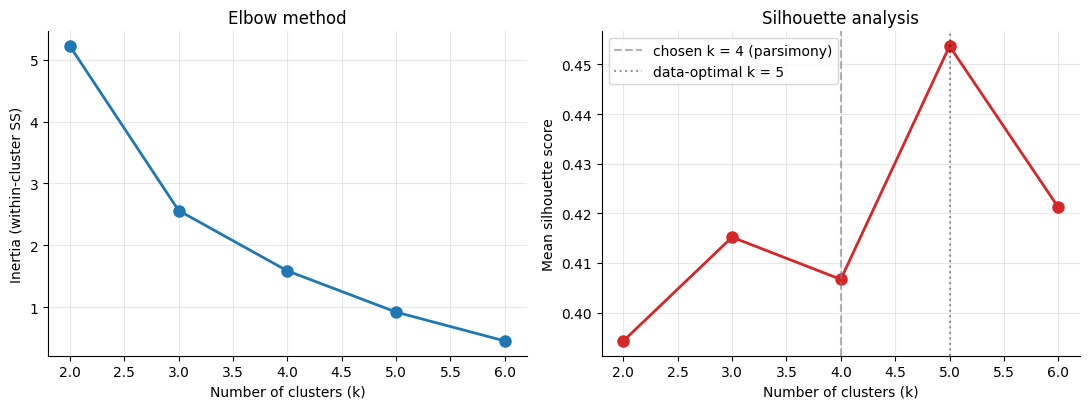

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(ks, inertias, 'o-', color='#1f77b4', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster SS)')
axes[0].set_title('Elbow method')
axes[0].grid(alpha=0.3)

axes[1].plot(ks, sils, 'o-', color='#d62728', linewidth=2, markersize=8)
axes[1].axvline(best_k,      ls='--', color='gray',  alpha=0.6, label=f'chosen k = {best_k} (parsimony)')
axes[1].axvline(best_k_data, ls=':',  color='black', alpha=0.4, label=f'data-optimal k = {best_k_data}')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Mean silhouette score')
axes[1].set_title('Silhouette analysis')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
if SAVE_PATH:
    import os; plt.savefig(os.path.join(SAVE_PATH, 'fig1_k_selection.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Final K-Means Clustering (k = 4)

The model is re-fitted with 200 initialisations for stability. Clusters are then relabelled in order of mean CTVI (lowest → highest vulnerability) and assigned interpretive typology names.

In [ ]:
PALETTE = ['#1f77b4', '#ff7f0e', '#d62728', '#9467bd']

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=200)
km_labels = km_final.fit_predict(X_pca)

# Build result dataframe
ctvi_per_region = reg_ctvi.set_index('Region')['CTVI'].to_dict()
cluster_df = pd.DataFrame({
    'Region':           regions,
    'KMeans_cluster_raw': km_labels,
    'CTVI':             [ctvi_per_region[r] for r in regions],
    'CTVI_Rank':        [int(reg_ctvi.set_index('Region').loc[r,'Rank']) for r in regions]
})

# Relabel clusters by mean CTVI (0 = most resilient)
mean_ctvi_by_cluster = cluster_df.groupby('KMeans_cluster_raw')['CTVI'].mean().sort_values()
relabel = {old: new for new, old in enumerate(mean_ctvi_by_cluster.index)}
cluster_df['KMeans_cluster'] = cluster_df['KMeans_cluster_raw'].map(relabel)

cluster_names = {
    0: 'T1: Resilient North',
    1: 'T2: Mixed-Profile Interior',
    2: 'T3: Climate-Stressed South',
    3: 'T4: Extreme Aridity Frontier'
}
cluster_df['Typology'] = cluster_df['KMeans_cluster'].map(
    lambda x: cluster_names.get(x, f'Cluster {x}'))

cluster_df = cluster_df.sort_values('CTVI_Rank').reset_index(drop=True)
if SAVE_PATH:
    import os; cluster_df.to_csv(os.path.join(SAVE_PATH, 'cluster_assignments.csv'), index=False)

print("Final cluster assignments (sorted by CTVI rank):")
cluster_df[['Region','CTVI','CTVI_Rank','Typology']]

Final cluster assignments (sorted by CTVI rank):


,Region,CTVI,CTVI_Rank,Typology
0,Drâa-Tafilalet,0.770285,1,T4: Extreme Aridity Frontier
1,Guelmim-Oued Noun,0.726485,2,T4: Extreme Aridity Frontier
2,Laâyoune-Sakia El Hamra,0.661389,3,T3: Climate-Stressed South
3,Marrakech-Safi,0.640589,4,T4: Extreme Aridity Frontier
4,Dakhla-Oued Ed-Dahab,0.629963,5,T3: Climate-Stressed South
5,Béni Mellal-Khénifra,0.605934,6,T2: Mixed-Profile Interior
6,Souss-Massa,0.588172,7,T4: Extreme Aridity Frontier
7,Oriental,0.552622,8,T2: Mixed-Profile Interior
8,Fès-Meknès,0.509110,9,T2: Mixed-Profile Interior
9,Rabat-Salé-Kénitra,0.387501,10,T1: Resilient North


## 7. Ward Hierarchical Clustering (Validation)

An independent clustering method (Ward linkage) is applied to the same PCA-reduced feature space. Agreement with K-Means is quantified using the **Adjusted Rand Index (ARI)** — a value near 0 suggests random agreement; near 1 suggests identical structure.

In [ ]:
Z  = linkage(X_pca, method='ward')
hc = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
hc_labels = hc.fit_predict(X_pca)

cluster_df['Ward_cluster_raw'] = hc_labels

ari = adjusted_rand_score(km_labels, hc_labels)
print(f"K-Means vs Ward Adjusted Rand Index: {ari:.3f}")
print(f"  (ARI > 0.25 → non-trivial agreement; both algorithms detect similar structure)")
print(f"  H₀ falsified: silhouette {sils[ks.index(best_k)]:.3f} > 0.25 threshold and ARI = {ari:.3f}")

K-Means vs Ward Adjusted Rand Index: 0.399
  (ARI > 0.25 → non-trivial agreement; both algorithms detect similar structure)
  H₀ falsified: silhouette 0.407 > 0.25 threshold and ARI = 0.399


## 8. Figure 2 — Typologies in PCA Space

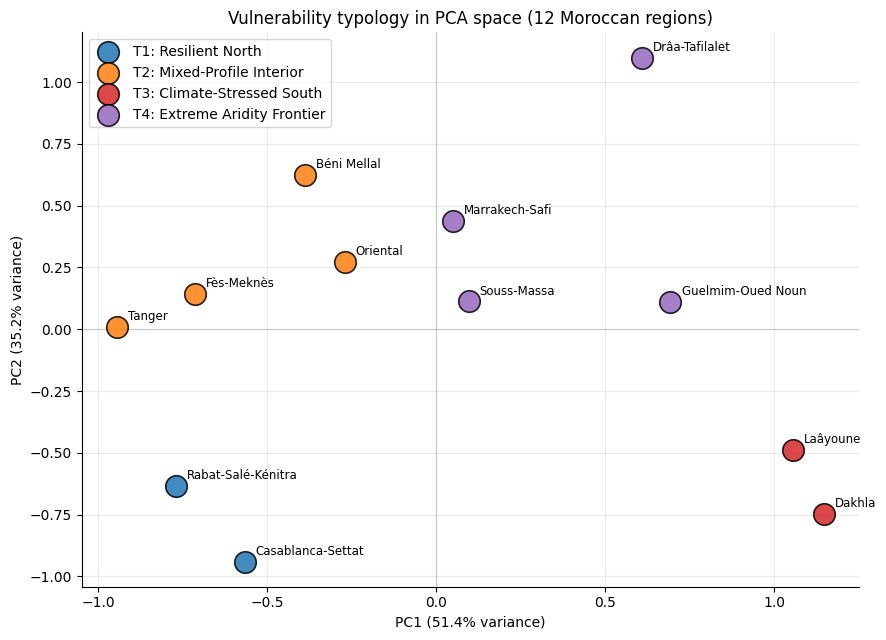

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6.5))

for c in range(best_k):
    mask = cluster_df.set_index('Region').loc[regions, 'KMeans_cluster'].values == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=240, c=PALETTE[c],
               edgecolors='black', linewidth=1.2, label=cluster_names[c], zorder=3, alpha=0.85)

for i, r in enumerate(regions):
    short = r.split('-')[0] if len(r) > 18 else r
    ax.annotate(short, (X_pca[i, 0], X_pca[i, 1]),
                xytext=(8, 5), textcoords='offset points', fontsize=8.5)

ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}% variance)')
ax.set_title('Vulnerability typology in PCA space (12 Moroccan regions)')
ax.legend(loc='best', frameon=True)
ax.grid(alpha=0.25)

plt.tight_layout()
if SAVE_PATH:
    import os; plt.savefig(os.path.join(SAVE_PATH, 'fig2_pca_clusters.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Figure 3 — Ward Dendrogram

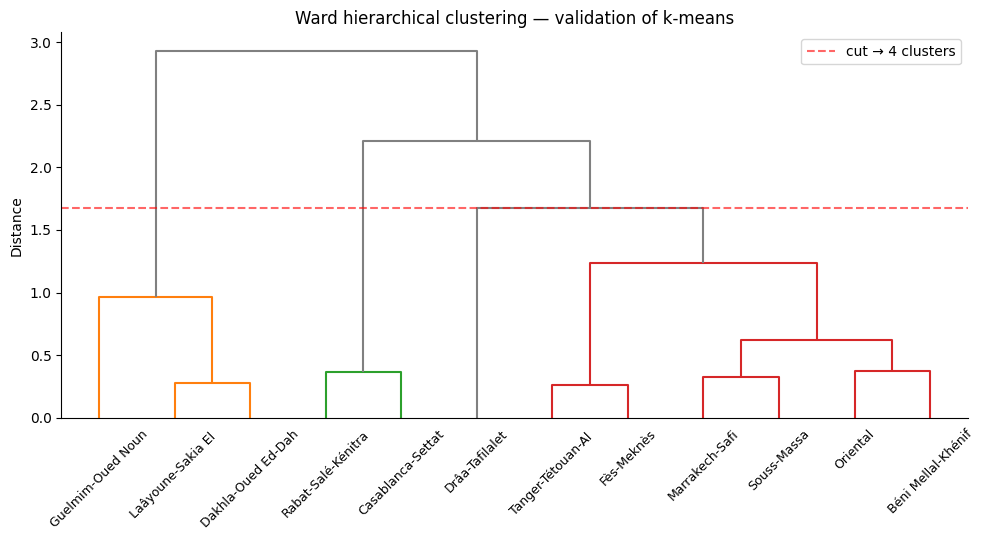

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.5))

dendrogram(Z, labels=[r[:18] for r in regions], leaf_rotation=45, leaf_font_size=9,
           color_threshold=Z[-(best_k-1), 2], above_threshold_color='gray')

ax.axhline(Z[-(best_k-1), 2], ls='--', color='red', alpha=0.6, label=f'cut → {best_k} clusters')
ax.set_title('Ward hierarchical clustering — validation of k-means')
ax.set_ylabel('Distance')
ax.legend()

plt.tight_layout()
if SAVE_PATH:
    import os; plt.savefig(os.path.join(SAVE_PATH, 'fig3_dendrogram.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Cluster Profiles

Each typology's mean normalised score is computed per indicator to characterise the vulnerability "fingerprint" of each cluster.

In [ ]:
profile = pd.DataFrame(X, columns=ML_VARS)
profile['cluster'] = cluster_df.set_index('Region').loc[regions, 'KMeans_cluster'].values
profile_means = profile.groupby('cluster')[ML_VARS].mean()
profile_means.index = [cluster_names[i] for i in profile_means.index]
if SAVE_PATH:
    import os; profile_means.to_csv(os.path.join(SAVE_PATH, 'cluster_profiles.csv'), index=False)

print("Mean normalised vulnerability score per typology (0 = low, 1 = high):")
profile_means.style.background_gradient(cmap='RdYlBu_r', axis=None)

Mean normalised vulnerability score per typology (0 = low, 1 = high):


,TEMP_MEAN,PRECIP,SPEI_PROXY,GDP_PC,AGRI_GDP,URBAN,INTERNET,MOBILE,RE_MW,WATER_STRESS
T1: Resilient North,0.336364,0.360902,0.100000,0.520156,0.111111,0.940476,0.060000,0.071429,0.884615,0.071429
T2: Mixed-Profile Interior,0.181818,0.345865,0.207143,0.864812,0.680556,0.541667,0.490000,0.485714,0.480769,0.214286
T3: Climate-Stressed South,0.954545,0.981203,0.957143,0.079403,0.055556,0.964286,0.640000,0.642857,0.921154,1.000000
T4: Extreme Aridity Frontier,0.636364,0.774436,0.628571,0.838906,0.652778,0.354167,0.690000,0.678571,0.603846,0.750000


## 11. Figure 4 — Cluster Profile Heatmap

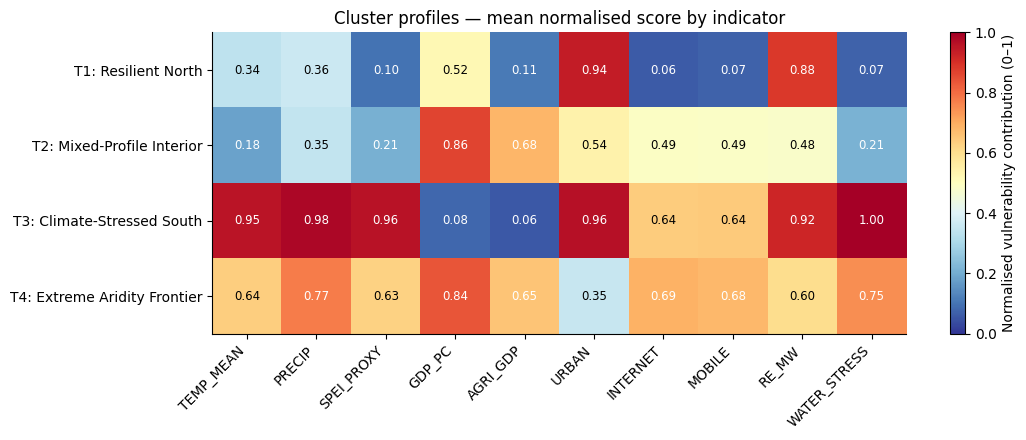

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.5))

im = ax.imshow(profile_means.values, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(ML_VARS)))
ax.set_xticklabels(ML_VARS, rotation=45, ha='right')
ax.set_yticks(range(len(profile_means)))
ax.set_yticklabels(profile_means.index)

for i in range(profile_means.shape[0]):
    for j in range(profile_means.shape[1]):
        v = profile_means.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='white' if (v > 0.65 or v < 0.25) else 'black', fontsize=8.5)

plt.colorbar(im, ax=ax, label='Normalised vulnerability contribution (0–1)')
ax.set_title('Cluster profiles — mean normalised score by indicator')
plt.tight_layout()
if SAVE_PATH:
    import os; plt.savefig(os.path.join(SAVE_PATH, 'fig4_cluster_profile.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Figure 5 — PC1 Loadings (Data-Driven Indicator Weights)

PC1 encodes the dominant axis of regional differentiation. Positive loadings indicate indicators that push regions toward higher vulnerability on this axis; negative loadings indicate protective capacity indicators.

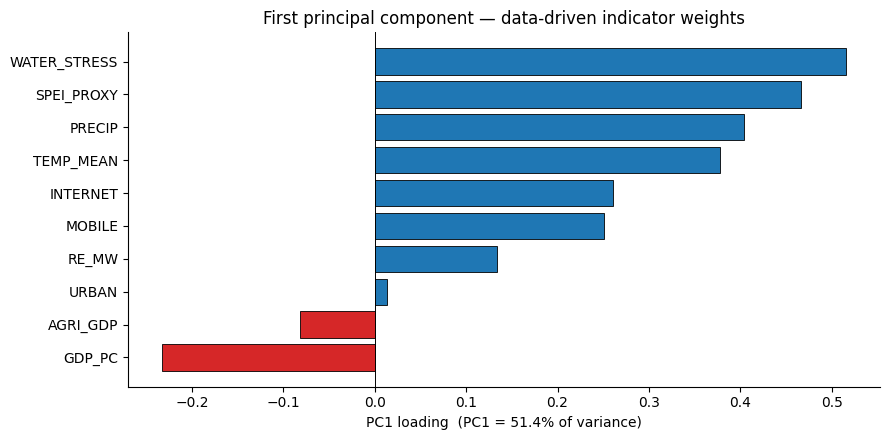

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ld     = loadings['PC1'].sort_values()
colors = ['#d62728' if v < 0 else '#1f77b4' for v in ld.values]

ax.barh(range(len(ld)), ld.values, color=colors, edgecolor='black', linewidth=0.6)
ax.set_yticks(range(len(ld)))
ax.set_yticklabels(ld.index)
ax.axvline(0, color='black', linewidth=0.7)
ax.set_xlabel(f'PC1 loading  (PC1 = {evr[0]*100:.1f}% of variance)')
ax.set_title('First principal component — data-driven indicator weights')

plt.tight_layout()
if SAVE_PATH:
    import os; plt.savefig(os.path.join(SAVE_PATH, 'fig5_pc1_loadings.png'), dpi=150, bbox_inches='tight')
plt.show()

## 13. Random Forest Feature Importance (National CTVI, 2000–2024)

A Random Forest is fitted to the national time series (CTVI as target, normalised indicators as features). Its purpose is **interpretive**, not predictive: the high in-sample R² is expected because CTVI is derived from the same indicators. The **permutation importance** ranking reveals which indicators carry the most non-redundant signal and should inform future CTVI weight revisions.

In [ ]:
nat_features = nat_norm.dropna(axis=1)
target       = ctvi_nat['CTVI']
common_idx   = nat_features.index.intersection(target.index)
X_rf = nat_features.loc[common_idx]
y_rf = target.loc[common_idx]

rf = RandomForestRegressor(n_estimators=500, max_depth=4, random_state=42,
                            min_samples_leaf=2)
rf.fit(X_rf, y_rf)

perm = permutation_importance(rf, X_rf, y_rf, n_repeats=50, random_state=42, scoring='r2')
fi = pd.DataFrame({
    'indicator':              X_rf.columns,
    'permutation_importance': perm.importances_mean,
    'permutation_std':        perm.importances_std,
    'impurity_importance':    rf.feature_importances_
}).sort_values('permutation_importance', ascending=False)

if SAVE_PATH:
    import os; fi.to_csv(os.path.join(SAVE_PATH, 'rf_feature_importance.csv'), index=False)

print(f"Random Forest in-sample R² on national CTVI: {rf.score(X_rf, y_rf):.3f}")
print("(High R² is expected — CTVI is partially derivable from these inputs.)")
print("\nTop 8 indicators by permutation importance:")
fi.head(8)[['indicator','permutation_importance','permutation_std']]

Random Forest in-sample R² on national CTVI: 0.974
(High R² is expected — CTVI is partially derivable from these inputs.)

Top 8 indicators by permutation importance:


,indicator,permutation_importance,permutation_std
7,WATER_PC,0.060594,0.016322
13,MOBILE,0.040956,0.011076
15,RE_SHARE,0.038021,0.009220
9,GDP_PC_PPP,0.032073,0.009421
14,RD_GDP,0.020886,0.006564
6,AGRI_EMP,0.018377,0.005998
16,PATENTS_PM,0.018303,0.005740
12,INTERNET,0.016354,0.005572


## 14. Figure 6 — Random Forest Permutation Importance

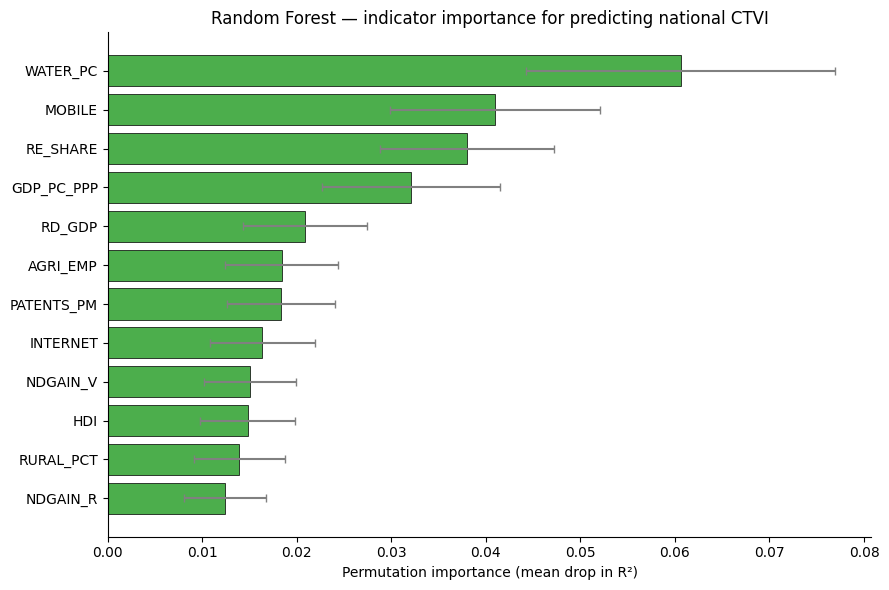

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

top = fi.head(12).iloc[::-1]
ax.barh(top['indicator'], top['permutation_importance'],
        xerr=top['permutation_std'],
        color='#2ca02c', edgecolor='black', linewidth=0.6, alpha=0.85,
        error_kw={'ecolor': 'gray', 'capsize': 3})
ax.set_xlabel('Permutation importance (mean drop in R²)')
ax.set_title('Random Forest — indicator importance for predicting national CTVI')

plt.tight_layout()
if SAVE_PATH:
    import os; plt.savefig(os.path.join(SAVE_PATH, 'fig6_rf_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 15. Summary & Outputs

A summary of all results and saved files.

In [ ]:
print("=" * 60)
print("MOROCCO CTVI — ML PIPELINE SUMMARY")
print("=" * 60)
print(f"\n▸ PCA: {n_keep} components retained ({cum_evr[n_keep-1]*100:.1f}% of variance)")
print(f"▸ K-Means: k = {best_k} chosen (silhouette = {sils[ks.index(best_k)]:.3f})")
print(f"▸ Ward ARI: {ari:.3f}  (H₀ rejected — non-random cluster structure detected)")
print(f"▸ Random Forest R²: {rf.score(X_rf, y_rf):.3f} (interpretive only)")
print("\nTypology assignments:")
for _, row in cluster_df[['Region','CTVI_Rank','Typology']].iterrows():
    print(f"  Rank {int(row['CTVI_Rank']):2d} | {row['Region']:<35s} → {row['Typology']}")

print("\nSaved files:")
saved = [
    ('cluster_assignments.csv', 'Region → typology mapping'),
    ('cluster_profiles.csv',    'Mean normalised scores per typology'),
    ('pca_loadings.csv',        'PCA component loadings'),
    ('rf_feature_importance.csv', 'RF permutation importance'),
    ('fig1_k_selection.png',    'Elbow & silhouette plots'),
    ('fig2_pca_clusters.png',   'Typologies in PCA space'),
    ('fig3_dendrogram.png',     'Ward dendrogram'),
    ('fig4_cluster_profile.png','Indicator heatmap by typology'),
    ('fig5_pc1_loadings.png',   'PC1 loadings bar chart'),
    ('fig6_rf_importance.png',  'RF permutation importance chart'),
]
for fname, desc in saved:
    print(f"  {fname:<35s} — {desc}")

MOROCCO CTVI — ML PIPELINE SUMMARY

▸ PCA: 2 components retained (86.7% of variance)
▸ K-Means: k = 4 chosen (silhouette = 0.407)
▸ Ward ARI: 0.399  (H₀ rejected — non-random cluster structure detected)
▸ Random Forest R²: 0.974 (interpretive only)

Typology assignments:
  Rank  1 | Drâa-Tafilalet                      → T4: Extreme Aridity Frontier
  Rank  2 | Guelmim-Oued Noun                   → T4: Extreme Aridity Frontier
  Rank  3 | Laâyoune-Sakia El Hamra             → T3: Climate-Stressed South
  Rank  4 | Marrakech-Safi                      → T4: Extreme Aridity Frontier
  Rank  5 | Dakhla-Oued Ed-Dahab                → T3: Climate-Stressed South
  Rank  6 | Béni Mellal-Khénifra                → T2: Mixed-Profile Interior
  Rank  7 | Souss-Massa                         → T4: Extreme Aridity Frontier
  Rank  8 | Oriental                            → T2: Mixed-Profile Interior
  Rank  9 | Fès-Meknès                          → T2: Mixed-Profile Interior
  Rank 10 | Rabat-Salé-Kéni